# MIOwAD - NN2

### Implementacja propagacji wstecznej błędu

W ramach tego laboratorium trzeba zaimplementować uczenie sieci neuronowej propagacją wsteczną błędu. Aby sprawdzić implementację, należy wykonać uczenie na prostych danych do uczenia dostarczonych na zajęciach. Następnie należy zaimplementować metodę wizualizacji wartości wag sieci w kolejnych iteracjach i, w przypadku gdy nie udaje się nauczyć sieci, spróbować wykorzystać te wizualizacje do ustalenia przyczyny problemu. Zaimplementować wersję z aktualizacją wag po prezentacji wszystkich wzorców i wersję z aktualizacją po prezentacji kolejnych porcji (batch). Porównać szybkość uczenia dla każdego z wariantów.

Inicjować wagi z rozkładu jednostajnego na przedziale $[0,1]$. Opcjonalnie zaimplementować inną metodą inicjowania wag. Albo metodę He albo Xavier.

Przetestować uczenie sieci na następujących zbiorach (w nawiasach wartość MSE, aby otrzymać 4 punkty):

- square-simple (jeśli sieć nie jest w stanie się nauczyć tej funkcji to coś jest bardzo źle zrobione, MSE: 4),
- steps-small (MSE: 8),
- multimodal-large (MSE: 40).

(Wartości MSE liczone na nieznormalizowanych danych)

In [1]:
import csv
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlp_engine import MLP_Network
from activation_functions import sigmoid, sigmoid_derivative, tanh, tanh_derivative, relu, relu_derivative

### Funkcje pomocnicze

In [2]:
def load_dataset(dataset_id):
    if dataset_id == 0:
        data = csv.reader(open('../mio1/regression/square-simple-training.csv'))
        test_data = csv.reader(open('../mio1/regression/square-simple-test.csv'))
    elif dataset_id == 1:
        data = csv.reader(open('../mio1/regression/steps-large-training.csv'))
        test_data = csv.reader(open('../mio1/regression/steps-large-test.csv'))
    elif dataset_id == 2:
        data = csv.reader(open('../mio1/regression/steps-small-training.csv'))
        test_data = csv.reader(open('../mio1/regression/steps-small-test.csv'))
    elif dataset_id == 3:
        data = csv.reader(open('../mio1/regression/multimodal-large-training.csv'))
        test_data = csv.reader(open('../mio1/regression/multimodal-large-test.csv'))
    else:
        assert False, f"Wybrana baza danych nie jest dostępna."

    # --- Przygotowanie danych uczących ---
    x_list = []
    y_list = []
    for i, row in enumerate(data):
        if i > 0:
            if dataset_id ==3:
                x, y = row
            else:
                _, x, y = row
            x_list.append(float(x))
            y_list.append(float(y))
            
    # --- Przygotowanie danych testowych ---
    test_x_list = []
    test_y_list = []
    for i, row in enumerate(test_data):
        if i > 0:
            if dataset_id ==3:
                x, y = row
            else:
                _, x, y = row
            test_x_list.append(float(x))
            test_y_list.append(float(y))

    X_train = np.array(x_list).reshape(-1, 1)
    Y_train = np.array(y_list).reshape(-1, 1)
    X_test = np.array(test_x_list).reshape(-1, 1)
    Y_test = np.array(test_y_list).reshape(-1, 1)

    return X_train, Y_train, X_test, Y_test


In [3]:
def visualize_mean_weights(results):
    plt.figure(figsize=(12, 5))

    for name, res in results.items():
        # Średnia wartość wag pierwszej warstwy w kolejnych epokach
        weight_means = [np.mean(h[0]) for h in res['history']]
        plt.plot(weight_means, label=name)
    
    plt.title("Wizualizacja zmian średnich wag (Warstwa 1)")
    plt.xlabel("Epoka")
    plt.ylabel("Średnia wartość wag")
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
def visualize_specific_weights(results, name=None):
    plt.figure(figsize=(12, 5))
    history = results['name']['history']
    
    # 3 pierwsze wagi łączące wejście z pierwszą warstwą ukrytą
    w1 = [h[0][0, 0] for h in history]
    w2 = [h[0][0, 1] for h in history]
    w3 = [h[0][0, 2] for h in history]
    
    plt.plot(w1, label='Waga 1 (Neuron 1)')
    plt.plot(w2, label='Waga 2 (Neuron 2)')
    plt.plot(w3, label='Waga 3 (Neuron 3)')
    
    plt.title("Trajektorie pojedynczych wag w warstwie 1 (Mini-batch)")
    plt.xlabel("Epoka")
    plt.ylabel("Wartość wagi")
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
def plot_loss_curves(results, name=None):
    """
    Rysuje krzywą uczenia (Loss vs Epoki).
    Jeśli name jest podane, rysuje tylko jeden wariant.
    """
    plt.figure(figsize=(10, 6))
    
    models_to_plot = {name: results[name]} if name else results
        
    for k, v in models_to_plot.items():
        # Używamy skali logarytmicznej na osi Y, jeśli błędy bardzo mocno spadają
        plt.plot(v['model'].loss_history, label=k, linewidth=1.5)
        
    plt.title("Krzywa uczenia (MSE na zbiorze treningowym w czasie)")
    plt.xlabel("Epoka")
    plt.ylabel("MSE (znormalizowane)")
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
def plot_predictions(results, X_test, y_test, x_min, x_max, y_min, y_max, name=None, normalization_method='0_1'):
    """
    Nakłada predykcje modelu na prawdziwe dane testowe.
    Sortuje wartości X, aby wykres linii był czytelny (a nie był "bazgrołem").
    """
    # Sortowanie danych wzdłuż osi X
    sort_idx = np.argsort(X_test[:, 0])
    X_sorted = X_test[sort_idx]
    y_sorted = y_test[sort_idx]
    
    # Przygotowanie znormalizowanych danych testowych
    if normalization_method == '-1_1':
        X_norm = 2 * (X_sorted - x_min) / (x_max - x_min) - 1
    else:
        X_norm = (X_sorted - x_min) / (x_max - x_min)

    # Predykcja
    model = results[name]['model']
    y_pred_norm = model.forward(X_norm)
    
    # Denormalizacja
    if normalization_method == '-1_1':
        y_pred = (y_pred_norm + 1) / 2 * (y_max - y_min) + y_min
    else:
        y_pred = y_pred_norm * (y_max - y_min) + y_min
    
    plt.figure(figsize=(10, 6))
    plt.scatter(X_sorted, y_sorted, color='black', alpha=0.5, label='Prawdziwe dane (Test)')
    plt.plot(X_sorted, y_pred, linewidth=3, label=f'Predykcja: {name}')
    plt.title(f'Wizualizacja dopasowania: {name} do danych testowych')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.legend()
    plt.show()


In [19]:
import pickle

def save_results(results_dict, filename="models.pkl"):
    """Zapisuje słownik z modelami do pliku."""
    with open(filename, 'wb') as f:
        pickle.dump(results_dict, f)
    print(f"Wyniki pomyślnie zapisane do pliku: {filename}")

def load_results(filename="models.pkl"):
    """Wczytuje słownik z modelami z pliku."""
    try:
        with open(filename, 'rb') as f:
            results_dict = pickle.load(f)
        print(f"Wyniki pomyślnie wczytane z pliku: {filename}")
        return results_dict
    except FileNotFoundError:
        print(f"Nie znaleziono pliku {filename}. Zwracam pusty słownik.")
        return {}

## 1. Zbadanie działania sieci na danych square-simple

In [3]:
X_train, y_train, X_test, y_test = load_dataset(dataset_id=0)

# Normalizacja Min-Max
x_min, x_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

X_norm = (X_train - x_min) / (x_max - x_min)
y_norm = (y_train - y_min) / (y_max - y_min)

In [11]:
layer_sizes = [1, 5, 1]
epochs = 3000
lr = 0.1
variants = [
    {'name': 'Full Batch', 'batch_size': X_norm.shape[0]},
    {'name': 'Mini-batch (32)', 'batch_size': 32},
    {'name': 'Online (Stochastic)', 'batch_size': 1}
]

results = {}

In [12]:
for v in variants:
    # Inicjalizacja wag z rozkładu jednostajnego [0, 1]
    mlp = MLP_Network(layer_sizes, sigmoid, sigmoid_derivative, 
                      last_layer_linear=True, init_method='uniform')
    
    start_time = time.time()
    mlp.train(X_norm, y_norm, epochs=epochs, lr=lr, batch_size=v['batch_size'])
    duration = time.time() - start_time
    
    # Predykcja i MSE (nieznormalizowane)
    y_pred_norm = mlp.forward(X_norm) 
    y_pred = y_pred_norm * (y_max - y_min) + y_min
    mse = np.mean((y_train - y_pred)**2)
    
    results[v['name']] = {
        'model': mlp, 
        'time': duration, 
        'mse': mse, 
        'history': mlp.weight_history}
    
    print(f"Wariant: {v['name']:18} | Czas: {duration:6.2f}s | MSE: {mse:8.4f}")

Wariant: Full Batch         | Czas:   0.27s | MSE: 7485.2808
Wariant: Mini-batch (32)    | Czas:   1.01s | MSE: 7045.1875
Wariant: Online (Stochastic) | Czas:  16.71s | MSE:   3.3893


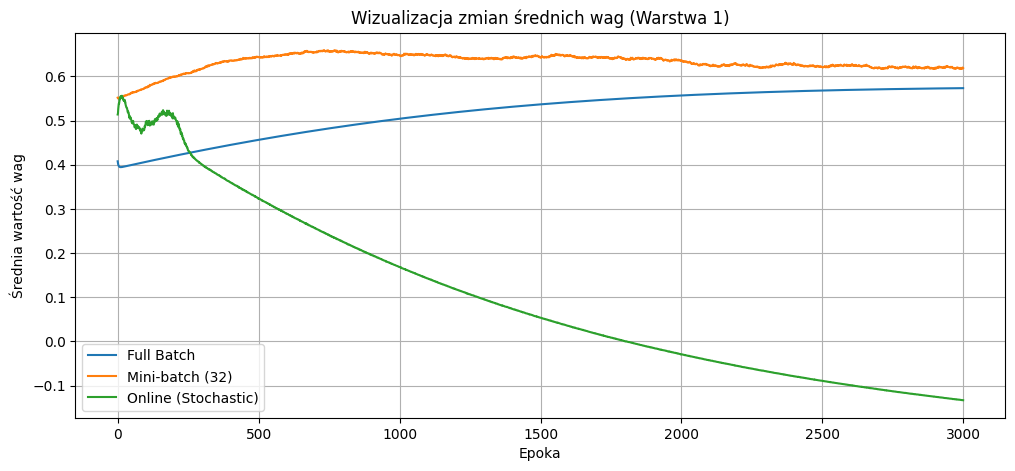

In [13]:
plt.figure(figsize=(12, 5))

for name, res in results.items():
    # Średnia wartość wag pierwszej warstwy w kolejnych epokach
    weight_means = [np.mean(h[0]) for h in res['history']]
    plt.plot(weight_means, label=name)

plt.title("Wizualizacja zmian średnich wag (Warstwa 1)")
plt.xlabel("Epoka")
plt.ylabel("Średnia wartość wag")
plt.legend()
plt.grid(True)
plt.show()

### Wizualizacja przestrzeni poszukiwań

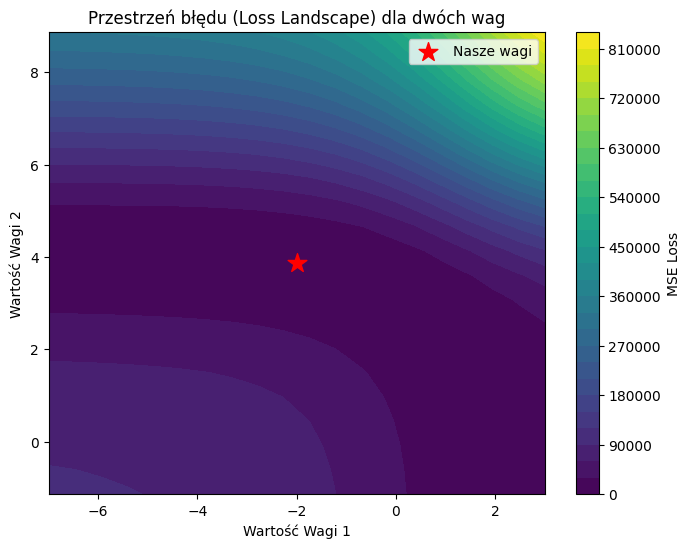

In [15]:
# Model
model_to_viz = results['Online (Stochastic)']['model']

# Oryginalne wagi
orig_W1 = model_to_viz.weights[0].copy()

# Dwie wagi do modyfikacji
w_idx1, w_idx2 = 0, 0
w_idx3, w_idx4 = 0, 1

# Siatka wartości wokół wyuczonych wag
w1_val = orig_W1[w_idx1, w_idx2]
w2_val = orig_W1[w_idx3, w_idx4]

w1_range = np.linspace(w1_val - 5, w1_val + 5, 20)
w2_range = np.linspace(w2_val - 5, w2_val + 5, 20)
W1_grid, W2_grid = np.meshgrid(w1_range, w2_range)
Loss_grid = np.zeros_like(W1_grid)

# Liczymy MSE dla każdego punktu na siatce
for i in range(W1_grid.shape[0]):
    for j in range(W1_grid.shape[1]):
        # Tymczasowa podmiana wag w modelu
        model_to_viz.weights[0][w_idx1, w_idx2] = W1_grid[i, j]
        model_to_viz.weights[0][w_idx3, w_idx4] = W2_grid[i, j]
        
        # Forward pass
        y_pred_temp = model_to_viz.forward(X_norm)
        y_pred_temp = y_pred_temp * (y_max - y_min) + y_min
        
        # Zapisujemy błąd
        Loss_grid[i, j] = np.mean((y_train - y_pred_temp)**2)

# Przywracamy oryginalne wagi
model_to_viz.weights[0] = orig_W1

# Rysowanie poziomic
plt.figure(figsize=(8, 6))
cp = plt.contourf(W1_grid, W2_grid, Loss_grid, levels=30, cmap='viridis')
plt.colorbar(cp, label='MSE Loss')

plt.scatter(w1_val, w2_val, color='red', marker='*', s=200, label='Nasze wagi')

plt.title("Przestrzeń błędu (Loss Landscape) dla dwóch wag")
plt.xlabel("Wartość Wagi 1")
plt.ylabel("Wartość Wagi 2")
plt.legend()
plt.show()

In [26]:
layer_sizes = [1, 10, 1]

variants = [
    {'name': 'Full Batch',          'batch_size': X_norm.shape[0], 'epochs': 50000, 'lr': 1},
    {'name': 'Mini-batch (32)',     'batch_size': 32,              'epochs': 15000,  'lr': 0.5},
    {'name': 'Online (Stochastic)', 'batch_size': 1,               'epochs': 3000,  'lr': 0.1}
]

results = {}

for v in variants:
    mlp = MLP_Network(layer_sizes, sigmoid, sigmoid_derivative, 
                      last_layer_linear=True, init_method='xavier')
    
    start_time = time.time()
    mlp.train(X_norm, y_norm, epochs=v['epochs'], lr=v['lr'], batch_size=v['batch_size'])
    duration = time.time() - start_time
    
    y_pred_norm = mlp.forward(X_norm) 
    y_pred = y_pred_norm * (y_max - y_min) + y_min
    mse = np.mean((y_train - y_pred)**2)
    
    results[v['name']] = {'model': mlp, 'time': duration, 'mse': mse, 'history': mlp.weight_history}
    print(f"Wariant: {v['name']:18} | Czas: {duration:6.2f}s | MSE: {mse:8.4f}")

Wariant: Full Batch         | Czas:   5.94s | MSE:   3.7429
Wariant: Mini-batch (32)    | Czas:   4.69s | MSE:   1.8026
Wariant: Online (Stochastic) | Czas:  17.44s | MSE:   0.6676


In [30]:
for v in variants:
    mlp = results[v['name']]['model']
    
    X_test_norm = (X_test - x_min) / (x_max - x_min)
    
    y_pred_test_norm = mlp.forward(X_test_norm) 
    y_pred_test = y_pred_test_norm * (y_max - y_min) + y_min

    mse_test = np.mean((y_test - y_pred_test)**2)
    
    print(f"Wariant: {v['name']:18} | TEST MSE: {mse_test:8.4f}")

Wariant: Full Batch         | TEST MSE:   4.0121
Wariant: Mini-batch (32)    | TEST MSE:   1.7386
Wariant: Online (Stochastic) | TEST MSE:   0.9014


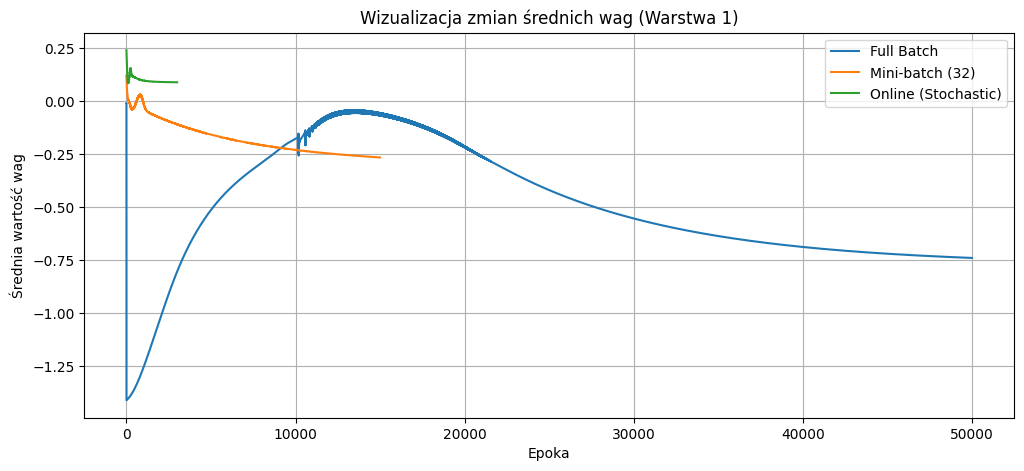

In [33]:
visualize_weights(results)

### Wnioski:
Przy wspólnej architekturze (1 warstwa ukryta z 10 neuronami) i metodzie inicjalizacji wag Xaviera każda sieć z odpowiednim rozmiarem batcha osiągnęła założone MSE < 4.

## 2. Sieci na danych steps-small

In [7]:
X_train, y_train, X_test, y_test = load_dataset(dataset_id=2)

In [8]:
def train_and_evaluate(variants_config, results_dict, X_train, y_train, X_test, y_test, 
                       layer_sizes, act_func, act_deriv, init_method='xavier', normalization_method='0_1'):
    """
    Funkcja trenująca modele z listy variants_config. 
    Jeśli model już istnieje w results_dict, zostanie on dotrenowany.
    normalization_method: '0_1' dla przedziału [0, 1] lub '-1_1' dla przedziału [-1, 1]
    """
    # Stałe normalizacji z danych treningowych
    x_min, x_max = X_train.min(), X_train.max()
    y_min, y_max = y_train.min(), y_train.max()

    if normalization_method == '-1_1':
        # Normalizacja do [-1, 1]
        X_train_norm = 2 * (X_train - x_min) / (x_max - x_min) - 1
        y_train_norm = 2 * (y_train - y_min) / (y_max - y_min) - 1
        X_test_norm = 2 * (X_test - x_min) / (x_max - x_min) - 1
    else:
        # Normalizacja danych do [0, 1]
        X_train_norm = (X_train - x_min) / (x_max - x_min)
        y_train_norm = (y_train - y_min) / (y_max - y_min)
        X_test_norm = (X_test - x_min) / (x_max - x_min)

    for v in variants_config:
        name = v['name']
        
        # Mechanizm dotrenowywania
        if name in results_dict and 'model' in results_dict[name]:
            mlp = results_dict[name]['model']
            previous_time = results_dict[name]['time']
            print(f"[*] DOTRENOWUJĘ istniejący model '{name}' o kolejne {v['epochs']} epok (lr={v['lr']})...")
        else:
            mlp = MLP_Network(layer_sizes, act_func, act_deriv, 
                              last_layer_linear=True, init_method=init_method)
            previous_time = 0.0
            print(f"[*] TWORZĘ NOWY model '{name}' i trenuję {v['epochs']} epok (lr={v['lr']})...")
        
        # Trening sieci
        start_time = time.time()
        mom = v.get('momentum', 0.0)
        mlp.train(X_train_norm, y_train_norm, epochs=v['epochs'], lr=v['lr'], 
                  batch_size=v['batch_size'], momentum=mom)
        current_time = time.time() - start_time
        total_time = previous_time + current_time
        
        # Predykcja i MSE na zbiorze testowym
        y_pred_test_norm = mlp.forward(X_test_norm)
        
        # Denormalizacja
        if normalization_method == '-1_1':
            y_pred_test = (y_pred_test_norm + 1) / 2 * (y_max - y_min) + y_min
        else:  
            y_pred_test = y_pred_test_norm * (y_max - y_min) + y_min

        mse_test = np.mean((y_test - y_pred_test)**2)
        
        # Zapisanie/Aktualizacja wyników w słowniku
        results_dict[name] = {
            'model': mlp, 
            'time': total_time,
            'mse': mse_test, 
            'history': mlp.weight_history
        }
        
        print(f"    -> Całkowity czas ukańczania: {total_time:6.2f}s | TEST MSE: {mse_test:8.4f}\n")
        
    return results_dict

### 2.1 Funkcja aktywacji sigmoid + inicjalizacja wag metodą Xavier

In [10]:
results_steps = {}

variants_steps = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 100000, 'lr': 1.0},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 30000,  'lr': 0.5},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 10000,  'lr': 0.05}
]

results_steps = train_and_evaluate(
    variants_steps, results_steps, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 10, 10, 1], act_func=sigmoid, act_deriv=sigmoid_derivative, init_method='xavier'
)

[*] TWORZĘ NOWY model 'Full Batch' i trenuję 100000 epok (lr=1.0)...
    -> Całkowity czas ukańczania:  23.15s | TEST MSE: 480.4145

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 30000 epok (lr=0.5)...
    -> Całkowity czas ukańczania:   9.73s | TEST MSE: 378.4520

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 10000 epok (lr=0.05)...
    -> Całkowity czas ukańczania:  50.45s | TEST MSE: 412.4763



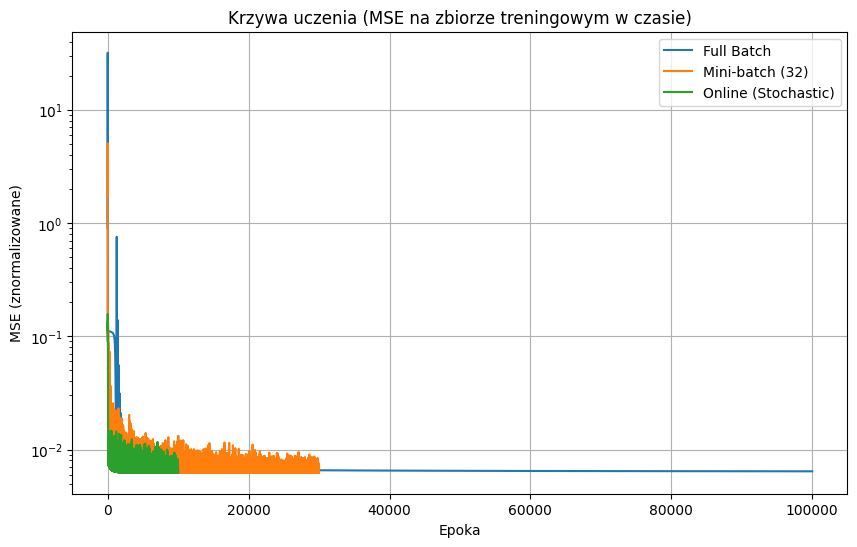

In [11]:
plot_loss_curves(results_steps)

[*] TWORZĘ NOWY model 'Full Batch' i trenuję 400000 epok (lr=0.1)...
    -> Całkowity czas ukańczania: 521.90s | TEST MSE: 426.7600

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 100000 epok (lr=0.05)...
    -> Całkowity czas ukańczania: 150.84s | TEST MSE: 524.1573

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 50000 epok (lr=0.005)...
    -> Całkowity czas ukańczania: 822.02s | TEST MSE: 422.3200



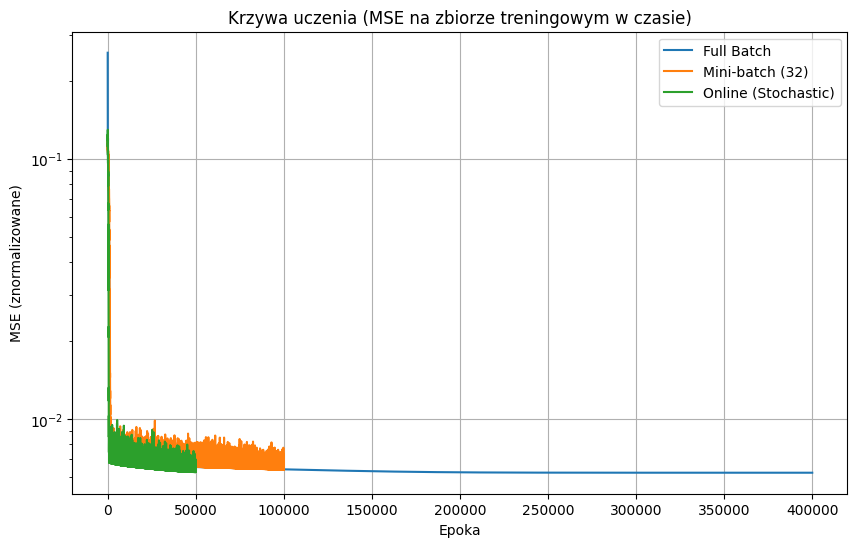

In [15]:
results_steps = {}

variants_steps = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 400000, 'lr': 0.1},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 100000,  'lr': 0.05},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 50000,  'lr': 0.005}
]

results_steps = train_and_evaluate(
    variants_steps, results_steps, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 50, 50, 1], act_func=sigmoid, act_deriv=sigmoid_derivative, init_method='xavier'
)

plot_loss_curves(results_steps)

### 2.2 Funkcja aktywacji Tanh + inicjalizacja wag metodą Xavier

[*] TWORZĘ NOWY model 'Full Batch' i trenuję 500000 epok (lr=0.1)...
    -> Całkowity czas ukańczania: 189.93s | TEST MSE: 110.0874

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 100000 epok (lr=0.05)...
    -> Całkowity czas ukańczania:  54.22s | TEST MSE: 288.4766

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 20000 epok (lr=0.005)...
    -> Całkowity czas ukańczania:  75.36s | TEST MSE: 375.4067



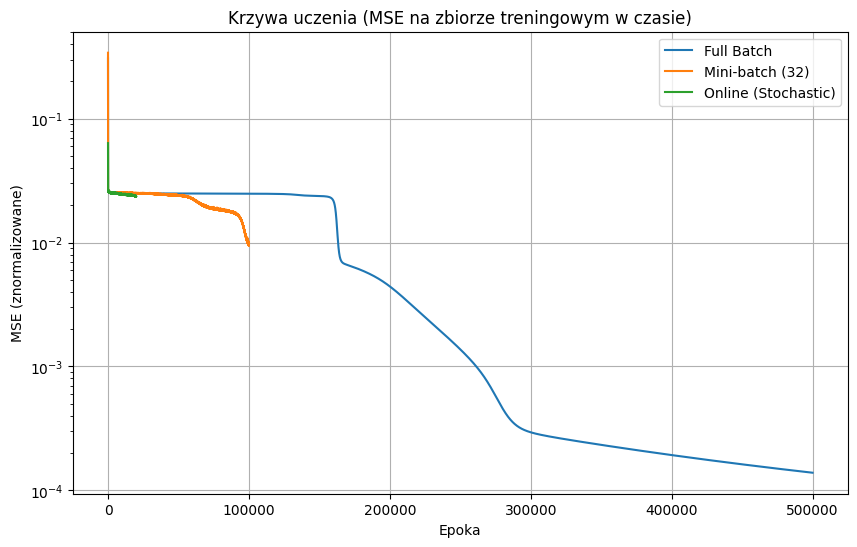

In [9]:
results_steps = {}

variants_steps = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 500000, 'lr': 0.1},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 100000,  'lr': 0.05},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 20000,  'lr': 0.005}
]

results_steps = train_and_evaluate(
    variants_steps, results_steps, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1], act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', normalization_method='-1_1'
)

plot_loss_curves(results_steps)

#### Obserwacja:
Widać, że sieci zaczęły się uczyć, można spróbować je dotrenować.

[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 300000 epok (lr=0.05)...
    -> Całkowity czas ukańczania: 316.79s | TEST MSE: 112.1553

[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 100000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 106.54s | TEST MSE: 214.4550

[*] DOTRENOWUJĘ istniejący model 'Online (Stochastic)' o kolejne 20000 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 183.56s | TEST MSE: 355.9035



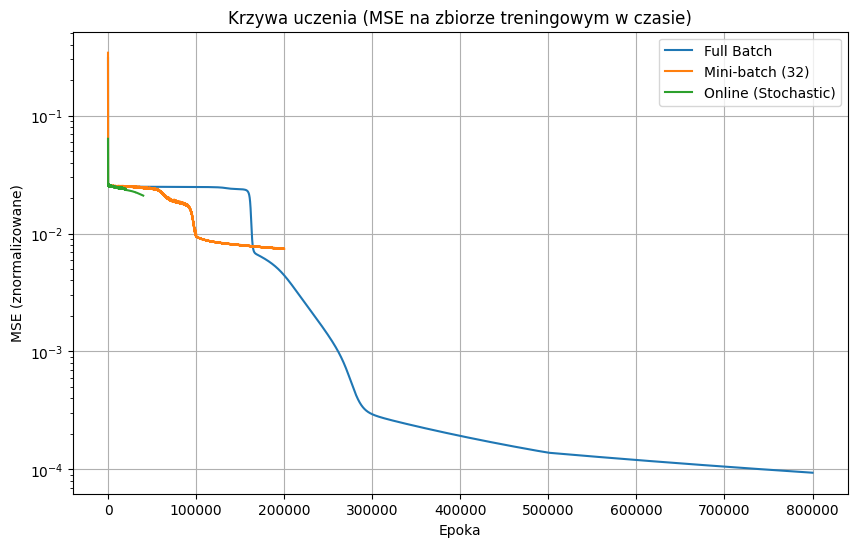

In [10]:
# Parametry do dotrenowania (zmniejszony learning rate)
variants_steps_finetune = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 300000, 'lr': 0.05},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 100000,  'lr': 0.01},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 20000,  'lr': 0.001}
]

# Dotrenowanie
results_steps = train_and_evaluate(
    variants_steps_finetune, 
    results_steps,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1], act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', normalization_method='-1_1'
)

plot_loss_curves(results_steps)

--- OSTATNIE DOTRENOWANIE NA TANH ---
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 200000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 395.80s | TEST MSE: 112.3721

[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 50000 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 131.03s | TEST MSE: 214.5612

[*] DOTRENOWUJĘ istniejący model 'Online (Stochastic)' o kolejne 10000 epok (lr=0.0005)...
    -> Całkowity czas ukańczania: 227.21s | TEST MSE: 351.0090



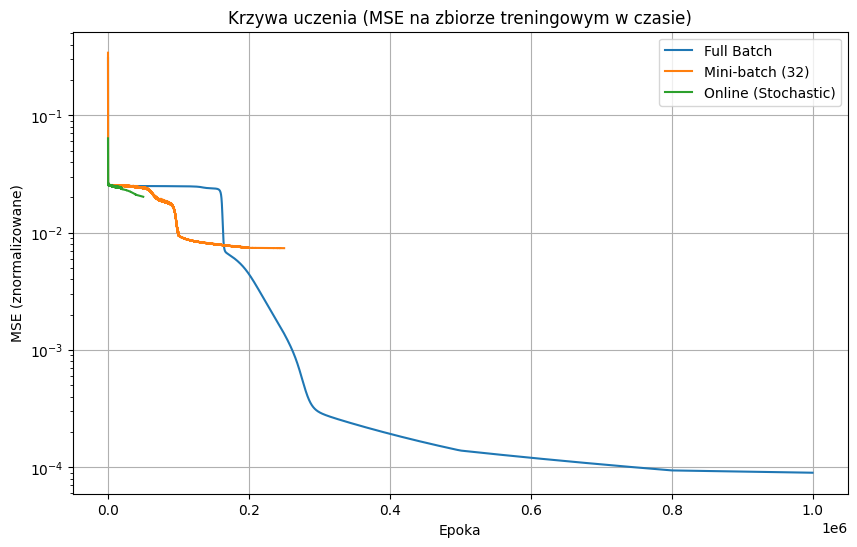

In [11]:
variants_tanh_final = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 200000, 'lr': 0.01},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 50000,  'lr': 0.001},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 10000,  'lr': 0.0005}
]

print("--- OSTATNIE DOTRENOWANIE NA TANH ---")
results_steps = train_and_evaluate(
    variants_tanh_final, 
    results_steps,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1], act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', normalization_method='-1_1'
)

plot_loss_curves(results_steps)

### Zmiana architektury

--- TANH (Bez Momentum) ---
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 100000 epok (lr=0.05)...
    -> Całkowity czas ukańczania:  34.74s | TEST MSE: 424.7937

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 50000 epok (lr=0.005)...
    -> Całkowity czas ukańczania:  19.20s | TEST MSE: 423.9559

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 10000 epok (lr=0.0005)...
    -> Całkowity czas ukańczania:  37.33s | TEST MSE: 438.6489



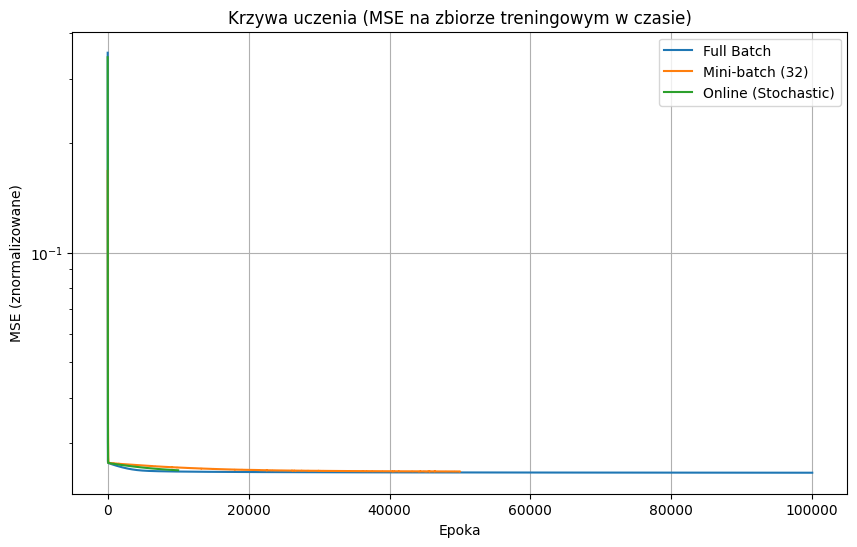

In [15]:
results_50 = {}

variants_50 = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 100000, 'lr': 0.05,  'momentum': 0.0},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 50000,  'lr': 0.005, 'momentum': 0.0},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 10000,  'lr': 0.0005, 'momentum': 0.0}
]

print("--- TANH (Bez Momentum) ---")
results_50 = train_and_evaluate(
    variants_50, 
    results_50, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 50, 50, 1],
    act_func=tanh, act_deriv=tanh_derivative,
    init_method='xavier',
    normalization_method='-1_1' 
)

plot_loss_curves(results_50)

### 2.3 Funkcja aktywacji ReLU + inicjalizacja wag metodą He

--- TRENING RELU + HE ---
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 100000 epok (lr=0.05)...
    -> Całkowity czas ukańczania:  15.56s | TEST MSE: 156.2885

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 30000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:   6.86s | TEST MSE: 339.2677

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 5000 epok (lr=0.001)...
    -> Całkowity czas ukańczania:  15.91s | TEST MSE: 414.5401



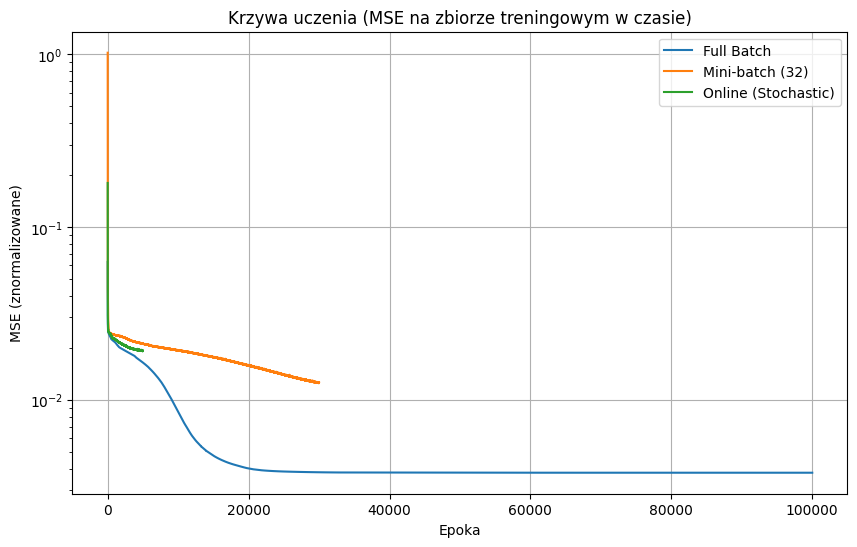

In [13]:
results_relu = {}

variants_relu = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 100000, 'lr': 0.05},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 30000,  'lr': 0.01},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 5000,   'lr': 0.001}
]

print("--- TRENING RELU + HE ---")
results_relu = train_and_evaluate(
    variants_relu, 
    results_relu,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1], 
    act_func=relu, act_deriv=relu_derivative, 
    init_method='he',
    normalization_method='-1_1'
)

plot_loss_curves(results_relu)

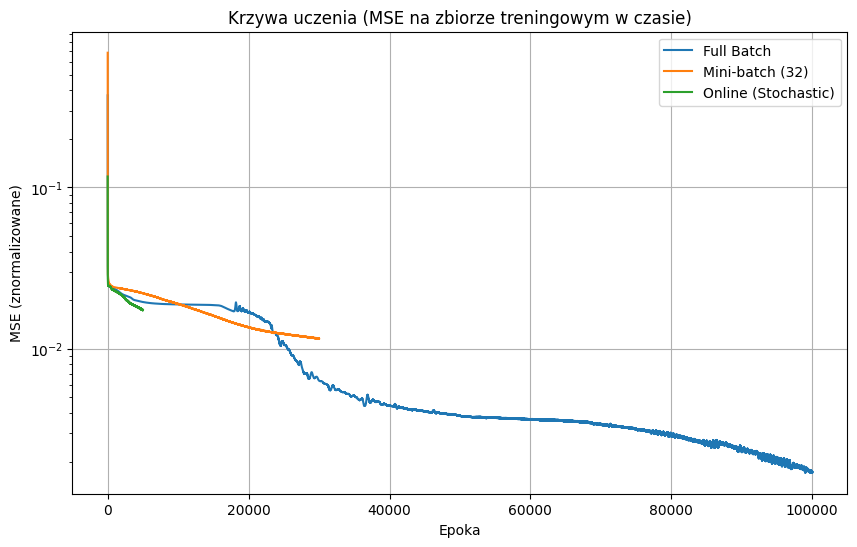

--- DOTRENOWANIE RELU ---
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 400000 epok (lr=0.025)...
    -> Całkowity czas ukańczania: 115.10s | TEST MSE: 156.0972

[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 150000 epok (lr=0.005)...
    -> Całkowity czas ukańczania:  57.65s | TEST MSE: 159.5799

[*] DOTRENOWUJĘ istniejący model 'Online (Stochastic)' o kolejne 30000 epok (lr=0.0005)...
    -> Całkowity czas ukańczania: 138.01s | TEST MSE: 458.4035



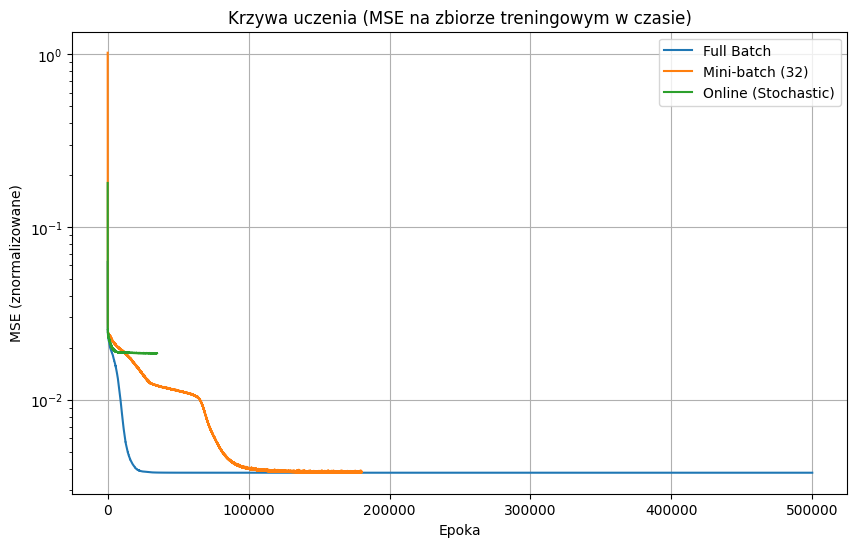

In [14]:
# Zmniejszenie LR + dodanie epok
variants_relu_finetune = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 400000, 'lr': 0.025},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 150000, 'lr': 0.005},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 30000,  'lr': 0.0005}
]

print("--- DOTRENOWANIE RELU ---")
results_relu = train_and_evaluate(
    variants_relu_finetune, 
    results_relu,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1], 
    act_func=relu, act_deriv=relu_derivative, 
    init_method='he', 
    normalization_method='-1_1' 
)

plot_loss_curves(results_relu)

### 2.4 ReLU + He + uczenie z momentem

In [10]:
results_momentum = {}

variants_momentum = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 40000, 'lr': 0.05,  'momentum': 0.9},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 20000, 'lr': 0.01,  'momentum': 0.9},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 5000,  'lr': 0.001, 'momentum': 0.9}
]

print("--- TRENING Z MOMENTUM (ReLU + He) ---")
results_momentum = train_and_evaluate(
    variants_momentum, 
    results_momentum,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1],
    act_func=relu, act_deriv=relu_derivative, 
    init_method='he', 
    normalization_method='-1_1' 
)

--- TRENING Z MOMENTUM (ReLU + He) ---
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 40000 epok (lr=0.05)...
    -> Całkowity czas ukańczania:   5.22s | TEST MSE: 463.1691

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 20000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:   3.89s | TEST MSE: 216.0656

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 5000 epok (lr=0.001)...
    -> Całkowity czas ukańczania:  14.72s | TEST MSE: 166.5622



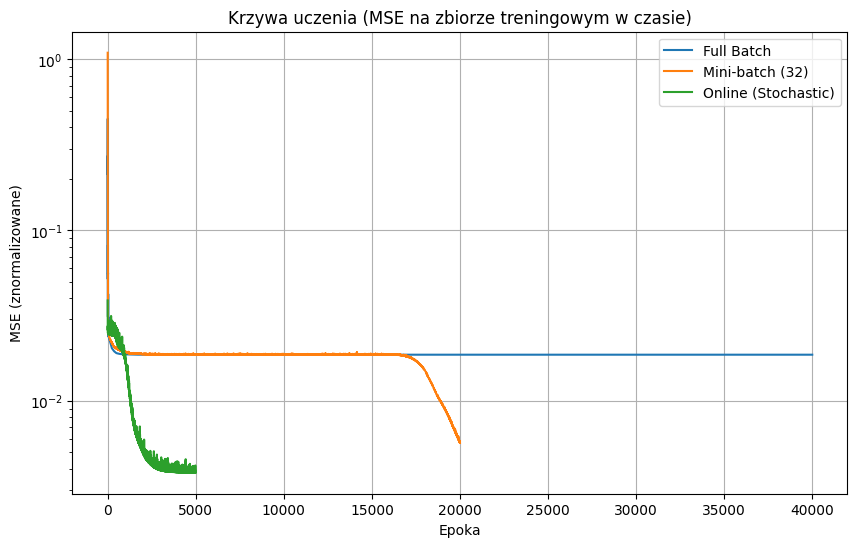

In [11]:
plot_loss_curves(results_momentum)

--- DOTRENOWANIE Z MOMENTUM ---
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 100000 epok (lr=0.005)...
    -> Całkowity czas ukańczania:  19.63s | TEST MSE: 463.1807

[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 50000 epok (lr=0.002)...
    -> Całkowity czas ukańczania:  14.64s | TEST MSE: 166.1153

[*] DOTRENOWUJĘ istniejący model 'Online (Stochastic)' o kolejne 20000 epok (lr=0.0002)...
    -> Całkowity czas ukańczania:  77.01s | TEST MSE: 160.2377



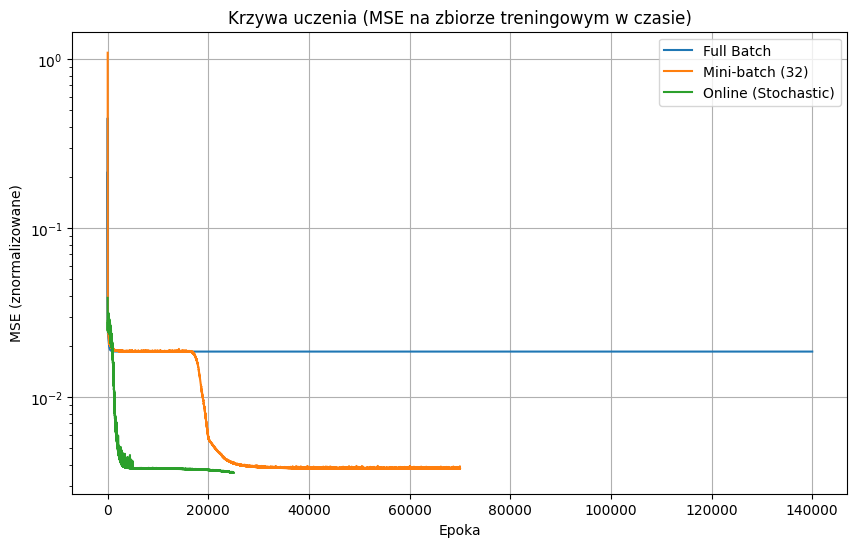

In [12]:
variants_momentum_finetune = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 100000, 'lr': 0.005, 'momentum': 0.9},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 50000,  'lr': 0.002, 'momentum': 0.9},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 20000,  'lr': 0.0002, 'momentum': 0.9}
]

print("--- DOTRENOWANIE Z MOMENTUM ---")
results_momentum = train_and_evaluate(
    variants_momentum_finetune, 
    results_momentum,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1], 
    act_func=relu, act_deriv=relu_derivative, 
    init_method='he', 
    normalization_method='-1_1' 
)

plot_loss_curves(results_momentum)

### 2.5 Brute force (tanh + $U[0, 1]$)

--- METODA SIŁOWA (z U[0,1]) ---
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 500000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 185.59s | TEST MSE: 205.5944

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 100000 epok (lr=0.01)...
    -> Całkowity czas ukańczania:  43.78s | TEST MSE: 251.7296

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 20000 epok (lr=0.001)...
    -> Całkowity czas ukańczania:  71.00s | TEST MSE: 282.2978



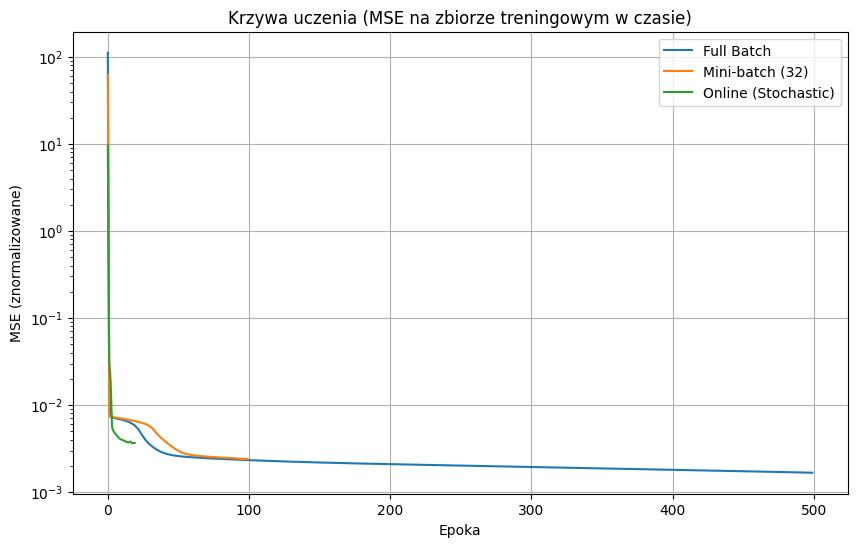

In [10]:
results_brute = {}

variants_brute = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 500000, 'lr': 0.01, 'momentum': 0.0},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 100000, 'lr': 0.01, 'momentum': 0.0},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 20000,  'lr': 0.001, 'momentum': 0.0}
]

print("--- METODA SIŁOWA (z U[0,1]) ---")
results_brute = train_and_evaluate(
    variants_brute, 
    results_brute, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='uniform',
    normalization_method='0_1'
)

plot_loss_curves(results_brute)

In [ ]:
variants_brute_finetune = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 1000000, 'lr': 0.005, 'momentum': 0.0},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 300000,  'lr': 0.005, 'momentum': 0.0},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 50000,   'lr': 0.0005, 'momentum': 0.0}
]

print("--- MASOWE DOTRENOWANIE SIŁOWE ---")
results_brute = train_and_evaluate(
    variants_brute_finetune, 
    results_brute,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='uniform', 
    normalization_method='0_1' 
)

plot_loss_curves(results_brute)

--- MASOWE DOTRENOWANIE SIŁOWE ---
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.005)...
    -> Całkowity czas ukańczania: 550.05s | TEST MSE: 179.2500

[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 300000 epok (lr=0.005)...


--- FULL BATCH: 5 MILIONÓW EPOK Z LR DECAY ---

[!] ETAP 1/5 | Bieżący LR: 0.01
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 1000000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 255.26s | TEST MSE: 171.1926


[!] ETAP 2/5 | Bieżący LR: 0.005
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.005)...
    -> Całkowity czas ukańczania: 511.52s | TEST MSE: 154.6186


[!] ETAP 3/5 | Bieżący LR: 0.0025
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.0025)...
    -> Całkowity czas ukańczania: 760.57s | TEST MSE: 147.3457


[!] ETAP 4/5 | Bieżący LR: 0.00125
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.00125)...
    -> Całkowity czas ukańczania: 1012.84s | TEST MSE: 144.4777


[!] ETAP 5/5 | Bieżący LR: 0.000625
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.000625)...
    -> Całkowity czas ukańczania: 1266.71s | TEST MSE: 143.2366



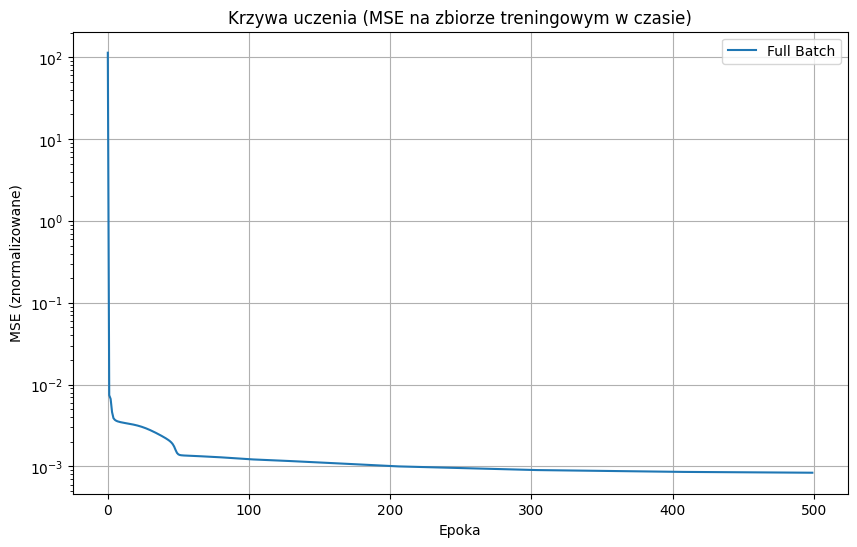

In [9]:
results_steps_brute = {}
initial_lr = 0.01
total_steps = 5

print("--- FULL BATCH: 5 MILIONÓW EPOK Z LR DECAY ---")

for i in range(total_steps):
    current_lr = initial_lr / (2**i)
    
    variant_loop = [{
        'name': 'Full Batch', 
        'batch_size': X_train.shape[0], 
        'epochs': 1000000, 
        'lr': current_lr, 
        'momentum': 0.0
    }]

    print(f"\n[!] ETAP {i+1}/{total_steps} | Bieżący LR: {current_lr}")

    results_steps_brute = train_and_evaluate(
        variant_loop, 
        results_steps_brute, 
        X_train, y_train, X_test, y_test, 
        layer_sizes=[1, 40, 40, 1],  
        act_func=tanh, act_deriv=tanh_derivative, 
        init_method='uniform', 
        normalization_method='0_1' 
    )

plot_loss_curves(results_steps_brute)

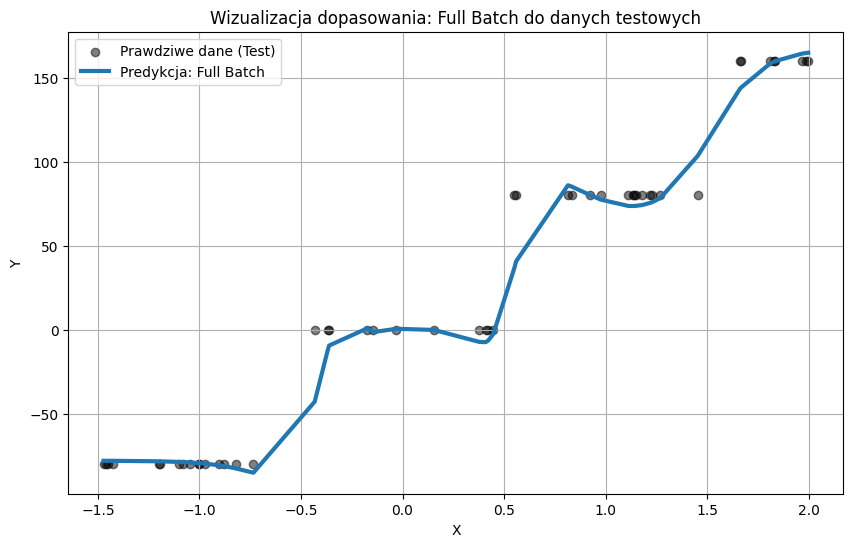

In [11]:
x_min, x_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

plot_predictions(results_steps_brute, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Full Batch', normalization_method='0_1')

In [13]:
variants_momentum_push = [{
    'name': 'Full Batch', 
    'batch_size': X_train.shape[0], 
    'epochs': 1000000, 
    'lr': 0.01, 
    'momentum': 0.9
}]

print("--- ETAP: MOMENTUM PUSH ---")

results_steps_brute = train_and_evaluate(
    variants_momentum_push, 
    results_steps_brute,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 40, 40, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='uniform', 
    normalization_method='0_1' 
)

--- ETAP: MOMENTUM PUSH ---
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 1532.16s | TEST MSE: 144.6615



--- FULL BATCH: 10 MILIONÓW EPOK ---

[!] ETAP 1/10 | Bieżący LR: 0.010000
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 1000000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 311.42s | TEST MSE: 159.7060


[!] ETAP 2/10 | Bieżący LR: 0.008000
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.008)...
    -> Całkowity czas ukańczania: 622.47s | TEST MSE: 136.9570


[!] ETAP 3/10 | Bieżący LR: 0.006400
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.006400000000000001)...
    -> Całkowity czas ukańczania: 935.74s | TEST MSE: 126.6040


[!] ETAP 4/10 | Bieżący LR: 0.005120
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.005120000000000001)...
    -> Całkowity czas ukańczania: 1269.03s | TEST MSE: 123.0023


[!] ETAP 5/10 | Bieżący LR: 0.004096
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.004096000000000001)...
    -> Całkowity czas ukańczania: 1597.23s | TEST MSE: 120.9985


[!

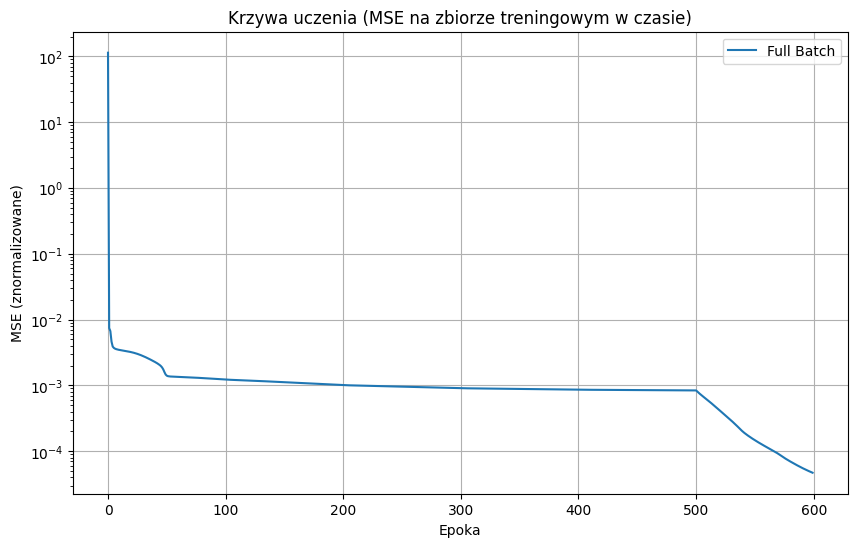

In [16]:
results_steps_brute2 = {}
initial_lr = 0.01
total_steps = 10

print("--- FULL BATCH: 10 MILIONÓW EPOK ---")

for i in range(total_steps):
    current_lr = initial_lr * (0.8 ** i) 
    
    variant_loop = [{
        'name': 'Full Batch', 
        'batch_size': X_train.shape[0], 
        'epochs': 1000000, 
        'lr': current_lr, 
        'momentum': 0.0
    }]

    print(f"\n[!] ETAP {i+1}/{total_steps} | Bieżący LR: {current_lr:.6f}")

    results_steps_brute2 = train_and_evaluate(
        variant_loop, 
        results_steps_brute2, 
        X_train, y_train, X_test, y_test, 
        layer_sizes=[1, 50, 50, 1], 
        act_func=tanh, act_deriv=tanh_derivative, 
        init_method='uniform',
        normalization_method='0_1' 
    )

plot_loss_curves(results_steps_brute)

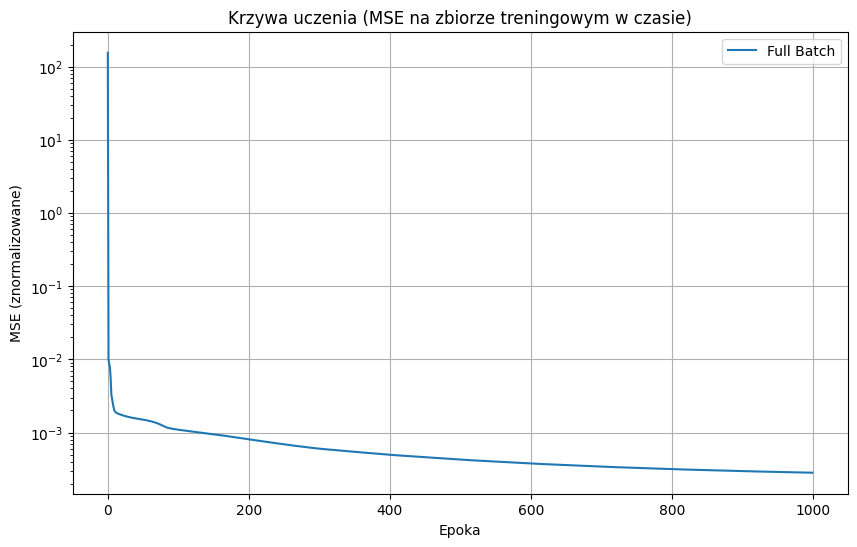

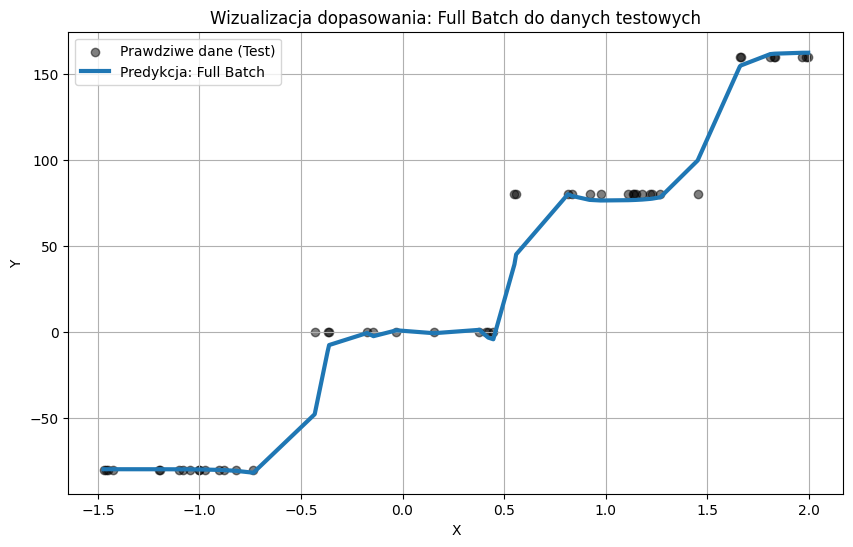

In [17]:
plot_loss_curves(results_steps_brute2)

plot_predictions(results_steps_brute2, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Full Batch', normalization_method='0_1')

In [21]:
# Zapis wyników / modeli
save_results(results_steps_brute2, "results_steps_small.pkl")

# Wczytanie wyników / modeli
# results_square = load_results("results_steps_small.pkl")

Wyniki pomyślnie zapisane do pliku: results_steps_small.pkl


In [22]:
variant_turbo = [{
    'name': 'Full Batch',
    'batch_size': 32, # zmiana na mini-batch 32
    'epochs': 1000000,
    'lr': 0.001,
    'momentum': 0.9
}]

print("--- FAZA TURBO: MINI-BATCH + MOMENTUM ---")
results_steps_brute3 = load_results("results_steps_small.pkl")

results_steps_brute3 = train_and_evaluate(
    variant_turbo, 
    results_steps_brute3, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 50, 50, 1], 
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='uniform', 
    normalization_method='0_1' 
)

--- FAZA TURBO: MINI-BATCH + MOMENTUM ---
Wyniki pomyślnie wczytane z pliku: results_steps_small.pkl
[*] DOTRENOWUJĘ istniejący model 'Full Batch' o kolejne 1000000 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 3818.50s | TEST MSE: 119.0630



## 3. Sieci dla danych multimodal-large

In [10]:
X_train, y_train, X_test, y_test = load_dataset(dataset_id=3)

--- TRENING: MULTIMODAL-LARGE ---
[*] TWORZĘ NOWY model 'Full Batch' i trenuję 500 epok (lr=0.1)...
    -> Całkowity czas ukańczania:  51.73s | TEST MSE: 2933.5939

[*] TWORZĘ NOWY model 'Mini-batch (64)' i trenuję 200 epok (lr=0.1)...
    -> Całkowity czas ukańczania:  17.74s | TEST MSE:  80.8667

[*] TWORZĘ NOWY model 'Mini-batch (32)' i trenuję 200 epok (lr=0.05)...
    -> Całkowity czas ukańczania:  17.61s | TEST MSE:  77.4304

[*] TWORZĘ NOWY model 'Online (Stochastic)' i trenuję 200 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 169.33s | TEST MSE:   3.8006



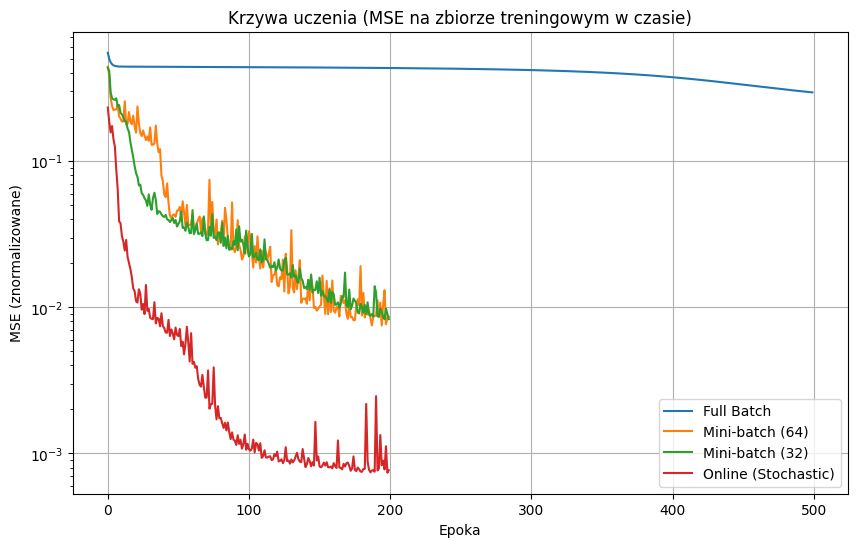

In [14]:
results_multi = {}

variants_multi = [
    {'name': 'Full Batch',          'batch_size': X_train.shape[0], 'epochs': 500, 'lr': 0.1,  'momentum': 0.0},
    {'name': 'Mini-batch (64)',     'batch_size': 64,               'epochs': 200, 'lr': 0.1,  'momentum': 0.0},
    {'name': 'Mini-batch (32)',     'batch_size': 32,               'epochs': 200, 'lr': 0.05,  'momentum': 0.0},
    {'name': 'Online (Stochastic)', 'batch_size': 1,                'epochs': 200, 'lr': 0.01, 'momentum': 0.0}
]

print("--- TRENING: MULTIMODAL-LARGE ---")
results_multi = train_and_evaluate(
    variants_multi, 
    results_multi, 
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 50, 50, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier',
    normalization_method='-1_1'
)

plot_loss_curves(results_multi)

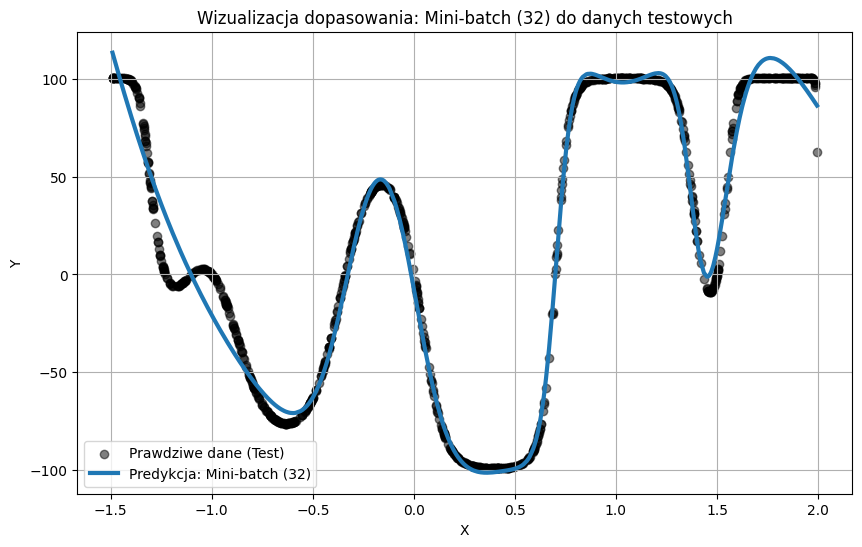

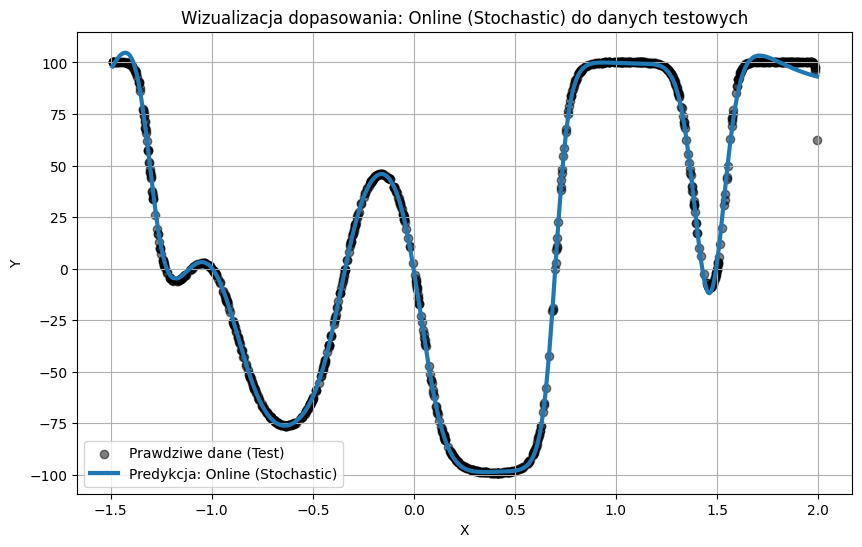

In [26]:
x_min, x_max = X_train.min(), X_train.max()
y_min, y_max = y_train.min(), y_train.max()

plot_predictions(results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Mini-batch (32)', normalization_method='-1_1')

plot_predictions(results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Online (Stochastic)', normalization_method='-1_1')

In [27]:
variants_multi_finetune = [
    {'name': 'Mini-batch (64)',     'batch_size': 64, 'epochs': 800, 'lr': 0.05,  'momentum': 0.0},
    {'name': 'Mini-batch (32)',     'batch_size': 32, 'epochs': 800, 'lr': 0.02,  'momentum': 0.0},
    {'name': 'Online (Stochastic)', 'batch_size': 1,  'epochs': 100, 'lr': 0.001, 'momentum': 0.0}
]

print("--- DOTRENOWANIE MULTIMODAL-LARGE ---")
results_multi = train_and_evaluate(
    variants_multi_finetune, 
    results_multi,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 50, 50, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', 
    normalization_method='-1_1' 
)

--- DOTRENOWANIE MULTIMODAL-LARGE ---
[*] DOTRENOWUJĘ istniejący model 'Mini-batch (64)' o kolejne 800 epok (lr=0.05)...
    -> Całkowity czas ukańczania: 114.51s | TEST MSE:   9.6399

[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 800 epok (lr=0.02)...
    -> Całkowity czas ukańczania: 102.93s | TEST MSE:  52.8798

[*] DOTRENOWUJĘ istniejący model 'Online (Stochastic)' o kolejne 100 epok (lr=0.001)...
    -> Całkowity czas ukańczania: 316.60s | TEST MSE:   3.0251



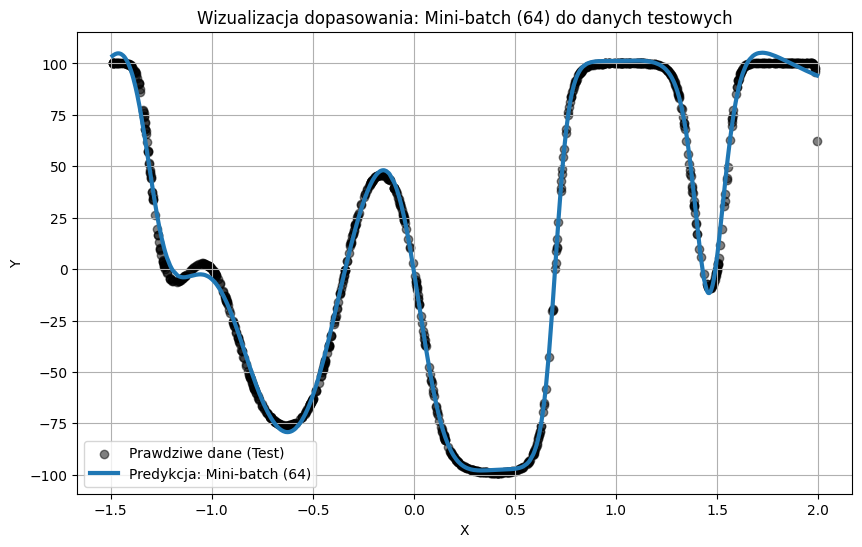

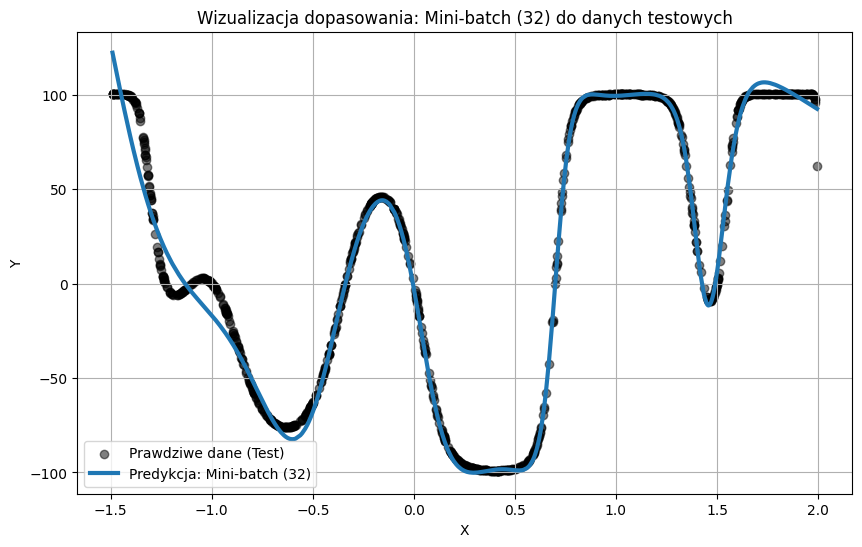

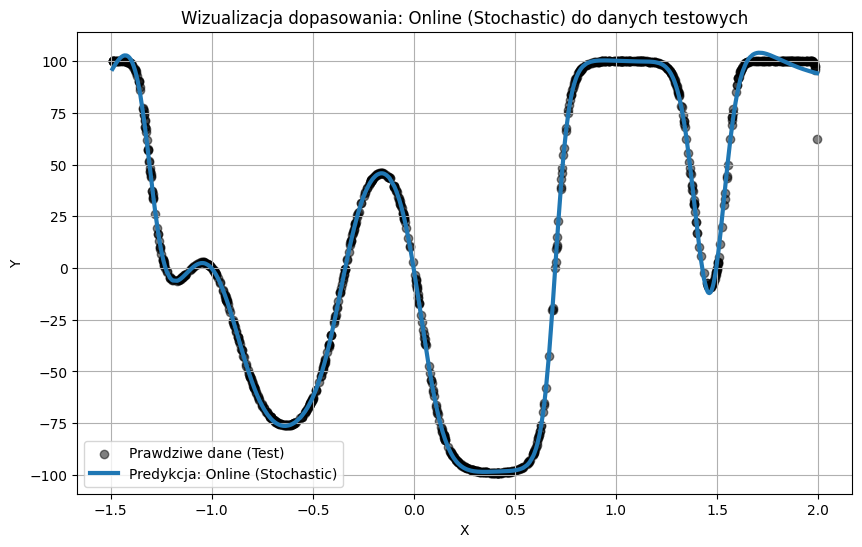

In [28]:
plot_predictions(results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Mini-batch (64)', normalization_method='-1_1')

plot_predictions(results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Mini-batch (32)', normalization_method='-1_1')

plot_predictions(results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Online (Stochastic)', normalization_method='-1_1')

--- Tylko Mini-batch (32) ---
[*] DOTRENOWUJĘ istniejący model 'Mini-batch (32)' o kolejne 2000 epok (lr=0.01)...
    -> Całkowity czas ukańczania: 386.25s | TEST MSE:   4.5184



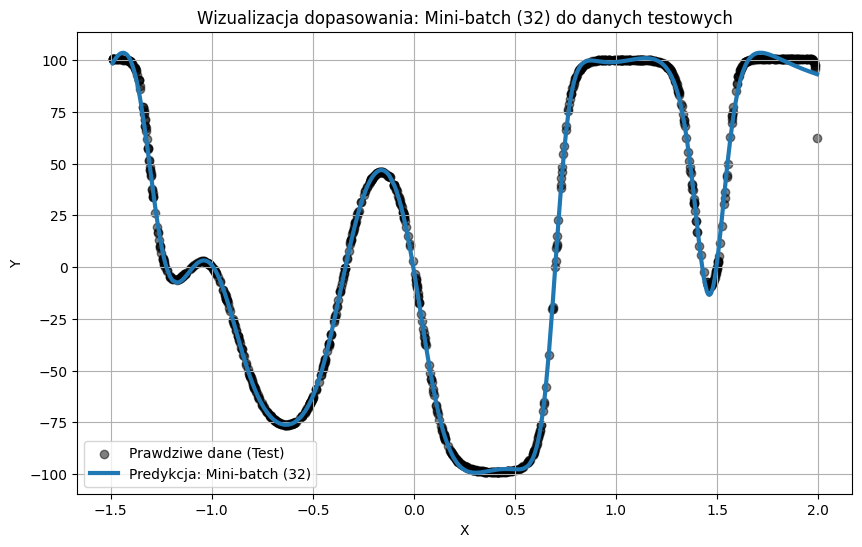

In [29]:
variants_multi_finetune_32 = [
    {'name': 'Mini-batch (32)', 'batch_size': 32, 'epochs': 2000, 'lr': 0.01, 'momentum': 0.0}
]

print("--- Tylko Mini-batch (32) ---")
results_multi = train_and_evaluate(
    variants_multi_finetune_32, 
    results_multi,
    X_train, y_train, X_test, y_test, 
    layer_sizes=[1, 50, 50, 1],  
    act_func=tanh, act_deriv=tanh_derivative, 
    init_method='xavier', 
    normalization_method='-1_1' 
)

plot_predictions(results_multi, X_test, y_test, x_min, x_max, y_min, y_max, 
                 name='Mini-batch (32)', normalization_method='-1_1')

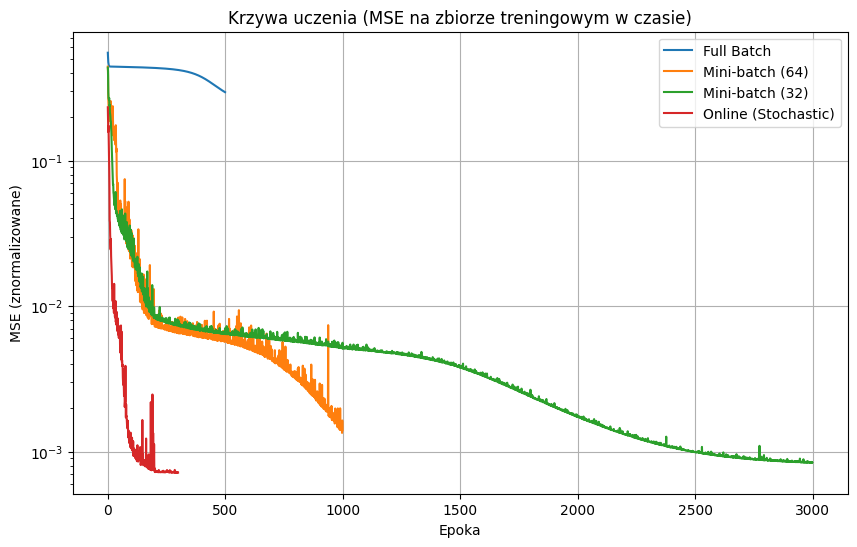

In [30]:
plot_loss_curves(results_multi)